# S&P 500 Stock Market — EDA, Time-Series and Forecasting

This notebook covers exploratory data analysis on S&P 500 stock prices and fundamentals, builds monthly time-series datasets, detects trends and seasonality, and forecasts prices and revenue for the next 12 months at both the company and sector level.

**Datasets used:**
- `prices-split-adjusted.csv` — daily adjusted closing prices
- `fundamentals.csv` — annual financial metrics per company
- `securities.csv` — company metadata including GICS sector


1. Imports and Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading

Place the three CSV files in the same directory as this notebook, or update `BASE` to the correct folder path.


In [ ]:
BASE = '.'   # update if files are elsewhere

prices     = pd.read_csv(os.path.join(BASE, 'prices.csv'))
prices_adj = pd.read_csv(os.path.join(BASE, 'prices-split-adjusted.csv'))
funds      = pd.read_csv(os.path.join(BASE, 'fundamentals.csv'))
sec        = pd.read_csv(os.path.join(BASE, 'securities.csv'))

print('prices     :', prices.shape)
print('prices_adj :', prices_adj.shape)
print('funds      :', funds.shape)
print('sec        :', sec.shape)

NameError: name 'pd' is not defined

In [3]:
print('--- prices ---')
display(prices.head(3))

print('--- prices_adj ---')
display(prices_adj.head(3))

print('--- fundamentals ---')
display(funds.head(3))

print('--- securities ---')
display(sec.head(3))

--- prices ---


,date,symbol,open,close,low,high,volume
0,1/5/2016 0:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600
1,1/6/2016 0:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400
2,1/7/2016 0:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500


--- prices_adj ---


,date,symbol,open,close,low,high,volume
0,1/5/2016,WLTW,123.430000,125.839996,122.309998,126.250000,2163600
1,1/6/2016,WLTW,125.239998,119.980003,119.940002,125.540001,2386400
2,1/7/2016,WLTW,116.379997,114.949997,114.930000,119.739998,2489500


--- fundamentals ---


,column1,ticker_symbol,period_ending,accounts_payable,accounts_receivable,additional_income_expense_items,after_tax_roe,capital_expenditures,capital_surplus,cash_ratio,...,total_current_assets,total_current_liabilities,total_equity,total_liabilities,total_liabilities_equity,total_revenue,treasury_stock,for_year,earnings_per_share,estimated_shares_outstanding
0,0,AAL,41274,3.068000e+09,-222000000,-1961000000,23,-1888000000,4.695000e+09,53,...,7.072000e+09,9011000000,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012,-5.6,335000000
1,1,AAL,41639,4.975000e+09,-93000000,-2723000000,67,-3114000000,1.059200e+10,75,...,1.432300e+10,13806000000,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013,-11.25,163022222.2
2,2,AAL,42004,4.668000e+09,-160000000,-150000000,143,-5311000000,1.513500e+10,60,...,1.175000e+10,13404000000,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014,4.02,716915422.9


--- securities ---


,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",3/31/1964,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",12/31/2012,1551152


## 3. Data Cleaning

Parse dates, extract time components, remove bad rows in fundamentals, cast numeric columns, and attach sector labels to both tables.


In [8]:
# Prices: parse dates and extract time parts
prices_adj['date']      = pd.to_datetime(prices_adj['date'])
prices_adj['year']      = prices_adj['date'].dt.year
prices_adj['month']     = prices_adj['date'].dt.month
prices_adj['yearmonth'] = prices_adj['date'].dt.to_period('M')

# Fundamentals: drop rows with invalid year values
funds = funds[~funds['for_year'].isin(['Null', '1215'])].copy()
funds['for_year'] = pd.to_numeric(funds['for_year'], errors='coerce')
funds = funds.dropna(subset=['for_year'])
funds['for_year'] = funds['for_year'].astype(int)

# Cast financial metric columns to float
numeric_cols = [
    'net_income', 'total_revenue', 'profit_margin', 'quick_ratio',
    'after_tax_roe', 'earnings_per_share', 'capital_expenditures',
    'total_equity', 'total_liabilities', 'research_and_development',
    'estimated_shares_outstanding',
]
for col in numeric_cols:
    funds[col] = pd.to_numeric(funds[col], errors='coerce')

# Sector lookup table
sec_map = (
    sec[['Ticker symbol', 'Security', 'GICS Sector']]
    .rename(columns={'Ticker symbol': 'ticker_symbol', 'GICS Sector': 'sector'})
)

# Attach sector to fundamentals
funds = funds.merge(sec_map, on='ticker_symbol', how='left')

# Attach sector to prices
prices = prices.merge(
    sec_map.rename(columns={'ticker_symbol': 'symbol'})[['symbol', 'sector']],
    on='symbol', how='left',
)

print('Cleaning complete.')
print(f'  prices rows  : {len(prices):,}')
print(f'  funds rows   : {len(funds):,}')
print(f'  sectors found: {prices["sector"].nunique()}')

Cleaning complete.
  prices rows  : 851,264
  funds rows   : 1,607
  sectors found: 11


## 4. Exploratory Data Analysis

### 4.1 Adjusted Close Price Distribution


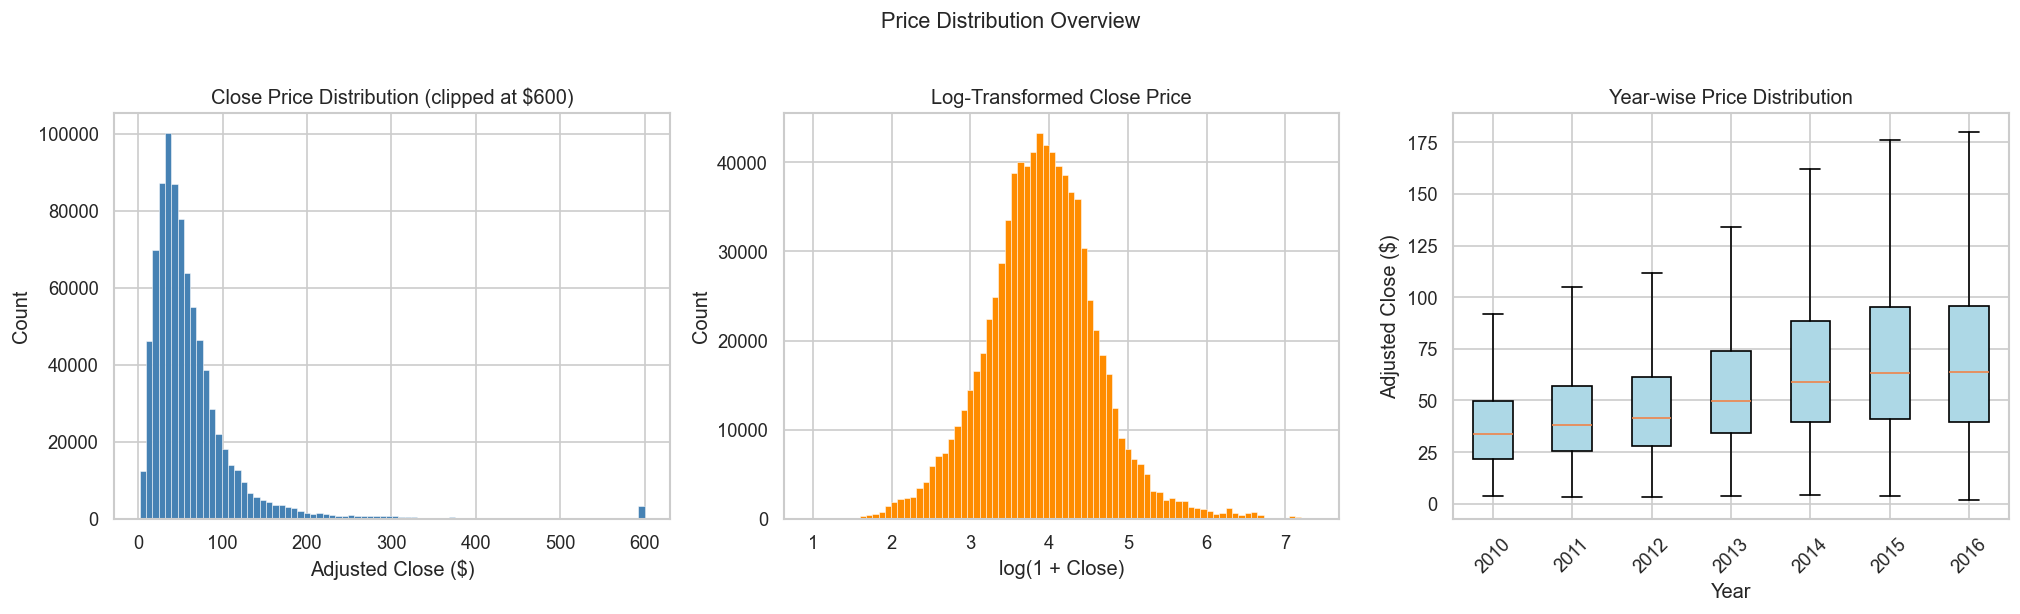

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Raw distribution clipped to remove extreme outliers for readability
axes[0].hist(prices_adj['close'].clip(0, 600), bins=80, color='steelblue',
             edgecolor='white', linewidth=0.3)
axes[0].set_title('Close Price Distribution (clipped at $600)')
axes[0].set_xlabel('Adjusted Close ($)')
axes[0].set_ylabel('Count')

# Log-transformed distribution
axes[1].hist(np.log1p(prices_adj['close']), bins=80, color='darkorange',
             edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Close Price')
axes[1].set_xlabel('log(1 + Close)')
axes[1].set_ylabel('Count')

# Year-wise box plot
years = sorted(prices_adj['year'].dropna().unique())
bp_data = [prices_adj[prices_adj['year'] == y]['close'].dropna().values for y in years]
axes[2].boxplot(bp_data, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_xticks(range(1, len(years) + 1))
axes[2].set_xticklabels([str(int(y)) for y in years], rotation=45)
axes[2].set_title('Year-wise Price Distribution')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Adjusted Close ($)')

plt.suptitle('Price Distribution Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Financial Metrics Over the Years

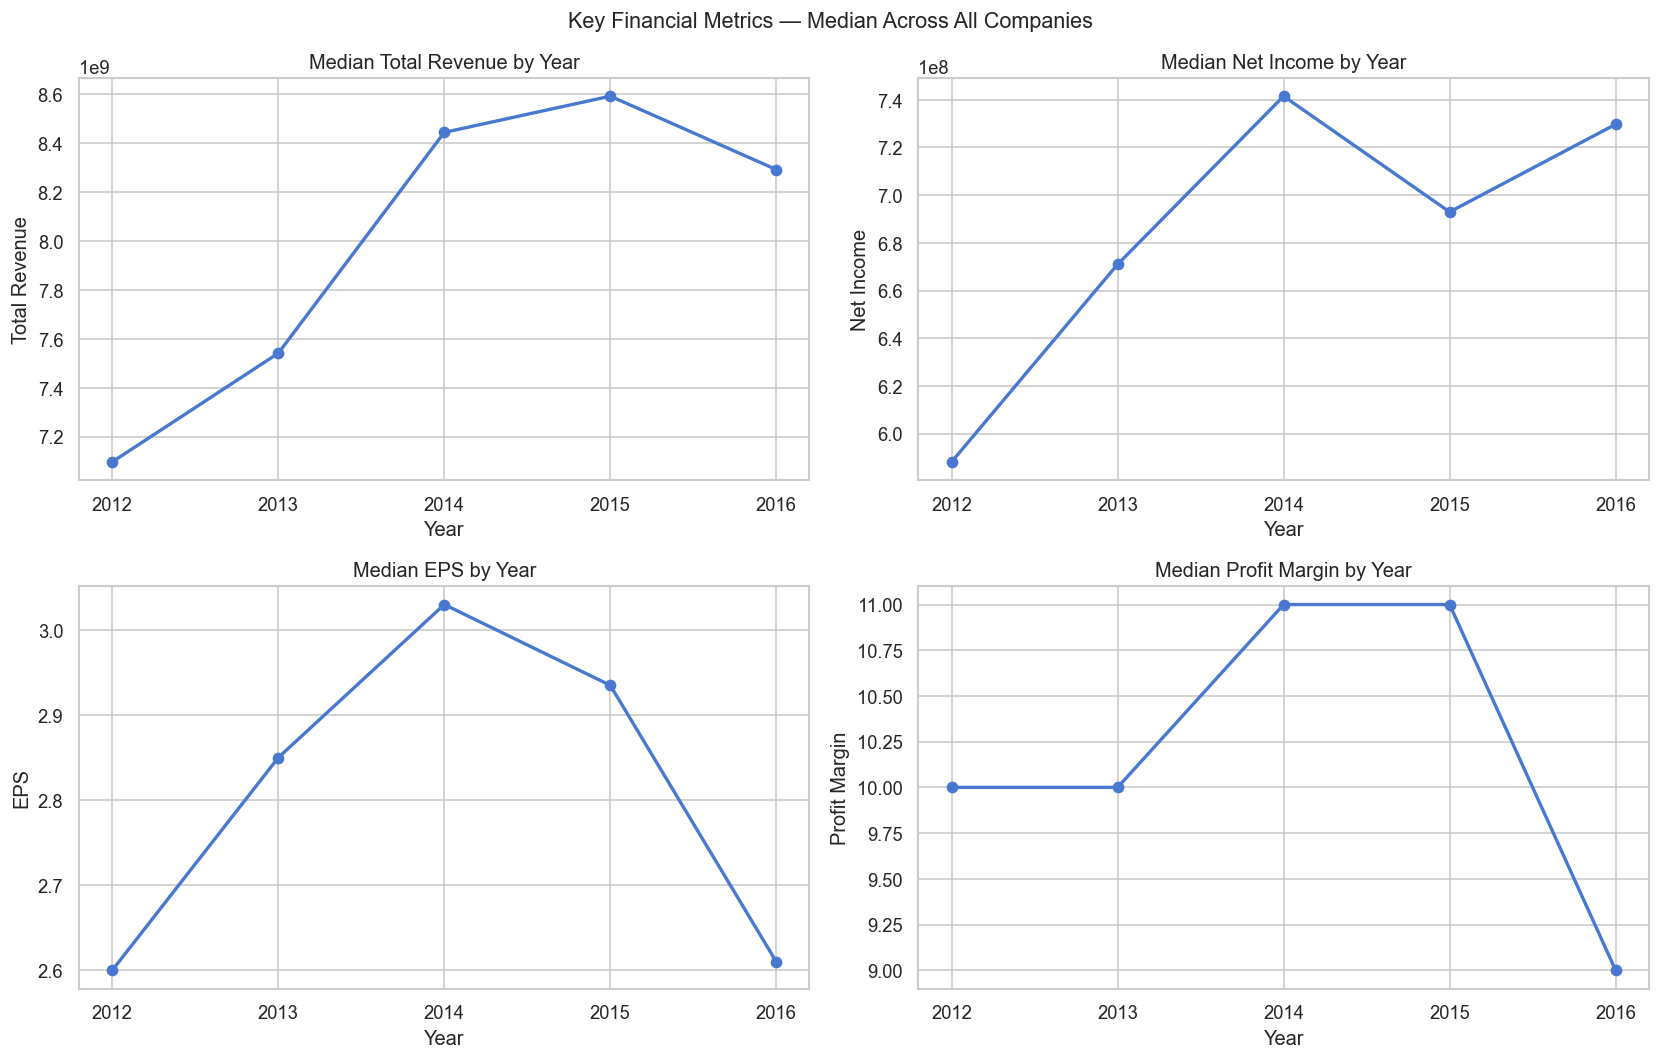

In [6]:
metrics = ['total_revenue', 'net_income', 'earnings_per_share', 'profit_margin']
labels  = ['Total Revenue', 'Net Income', 'EPS', 'Profit Margin']

yearly = funds.groupby('for_year')[metrics].median().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col, label in zip(axes.flat, metrics, labels):
    ax.plot(yearly['for_year'], yearly[col], marker='o', linewidth=2)
    ax.set_title(f'Median {label} by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Key Financial Metrics — Median Across All Companies', fontsize=13)
plt.tight_layout()
plt.show()

### 4.3 Sector-wise Patterns

In [ ]:
# Median revenue per sector
sector_rev = (
    funds.dropna(subset=['sector'])
    .groupby('sector')['total_revenue']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — median revenue by sector
sns.barplot(data=sector_rev, x='total_revenue', y='sector', ax=axes[0], palette='Blues_r')
axes[0].set_title('Median Total Revenue by GICS Sector')
axes[0].set_xlabel('Median Revenue')
axes[0].set_ylabel('Sector')

# Heatmap — average financial metrics per sector
heat_df = (
    funds.dropna(subset=['sector'])
    .groupby('sector')[['profit_margin', 'after_tax_roe', 'quick_ratio', 'earnings_per_share']]
    .mean()
)
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())
sns.heatmap(heat_norm, annot=heat_df.round(2), fmt='g', cmap='YlGnBu',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Normalised Financial Metrics by Sector')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Sector')

plt.tight_layout()
plt.show()

## 5. Time-Series Dataset Creation

### 5.1 Monthly Average Adjusted Closing Price


In [ ]:
monthly_price = (
    prices_adj.groupby(['symbol', 'yearmonth'])['close']
    .mean()
    .reset_index()
    .rename(columns={'close': 'avg_close'})
)
monthly_price['yearmonth'] = monthly_price['yearmonth'].dt.to_timestamp()
monthly_price = monthly_price.sort_values(['symbol', 'yearmonth'])

print('Monthly price dataset shape:', monthly_price.shape)
display(monthly_price.head())

### 5.2 Monthly Revenue (Approximated from Fundamentals)

In [ ]:
# Annual revenue divided by 12 gives an approximate monthly figure
monthly_rev = funds[['ticker_symbol', 'for_year', 'total_revenue', 'sector']].copy()
monthly_rev = monthly_rev.dropna(subset=['total_revenue'])
monthly_rev['monthly_revenue'] = monthly_rev['total_revenue'] / 12

print('Monthly revenue dataset shape:', monthly_rev.shape)
display(monthly_rev.head())

## 6. Trend and Seasonality Detection

We use a polynomial regression model to capture the overall trend and a 12-month rolling average to smooth short-term noise. Residuals from the trend reveal any seasonal patterns.

### 6.1 Select Top 5 Companies by Data Availability


In [ ]:
top5 = (
    monthly_price.groupby('symbol')['avg_close']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print('Top 5 companies selected:', top5)

### 6.2 Rolling Average and Trend Line

In [ ]:
fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4 * len(top5)), sharex=False)

for ax, sym in zip(axes, top5):
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    # Polynomial trend (degree 2)
    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    df_sym['trend'] = model.predict(df_sym[['t']])

    # 12-month rolling average
    df_sym['rolling_12'] = df_sym['avg_close'].rolling(12, min_periods=1).mean()

    ax.plot(df_sym['yearmonth'], df_sym['avg_close'],  alpha=0.5, label='Monthly Avg Close')
    ax.plot(df_sym['yearmonth'], df_sym['rolling_12'], linewidth=2, label='12M Rolling Avg')
    ax.plot(df_sym['yearmonth'], df_sym['trend'],      linewidth=2, linestyle='--', label='Poly Trend')
    ax.set_title(f'{sym} — Price Trend')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Seasonal Residual Analysis

In [ ]:
fig, axes = plt.subplots(1, len(top5), figsize=(16, 4), sharey=False)

for ax, sym in zip(axes, top5):
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    df_sym['residual'] = df_sym['avg_close'] - model.predict(df_sym[['t']])

    df_sym['cal_month'] = pd.to_datetime(df_sym['yearmonth']).dt.month
    seasonal = df_sym.groupby('cal_month')['residual'].mean()

    ax.bar(seasonal.index, seasonal.values, color='teal', edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(sym)
    ax.set_xlabel('Month')
    ax.set_xticks(range(1, 13))

axes[0].set_ylabel('Average Residual ($)')
plt.suptitle('Average Seasonal Residual by Calendar Month', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Price Forecasting — Next 12 Months (Top 5 Companies)

The polynomial trend model trained on historical data is extended 12 months into the future.


In [ ]:
forecast_records = []

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4 * len(top5)), sharex=False)

for ax, sym in zip(axes, top5):
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    df_sym['fitted'] = model.predict(df_sym[['t']])

    last_t     = df_sym['t'].max()
    last_date  = df_sym['yearmonth'].max()
    future_t   = np.arange(last_t + 1, last_t + 13).reshape(-1, 1)
    future_dates  = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')
    future_prices = model.predict(future_t).clip(0)

    ax.plot(df_sym['yearmonth'], df_sym['avg_close'], alpha=0.4, label='Historical')
    ax.plot(df_sym['yearmonth'], df_sym['fitted'],    linewidth=2, linestyle='--', label='Trend Fit')
    ax.plot(future_dates, future_prices,              linewidth=2.5, color='crimson', label='Forecast')
    ax.axvline(last_date, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{sym} — 12-Month Price Forecast')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend(fontsize=8)

    for date, price in zip(future_dates, future_prices):
        forecast_records.append({'symbol': sym, 'date': date, 'forecast_close': round(price, 2)})

plt.tight_layout()
plt.show()

In [ ]:
forecast_df = pd.DataFrame(forecast_records)
print(f'Forecast rows: {len(forecast_df)}')
display(forecast_df.head(15))

forecast_df.to_csv('forecast_top5_prices.csv', index=False)
print('Saved: forecast_top5_prices.csv')

## 8. Category-Level Forecasting — Revenue by GICS Sector

Annual total revenue is aggregated by sector, then a linear trend model forecasts the next 3 years.


In [ ]:
sector_annual = (
    funds.dropna(subset=['sector', 'total_revenue'])
    .groupby(['sector', 'for_year'])['total_revenue']
    .sum()
    .reset_index()
    .rename(columns={'total_revenue': 'total_revenue_sum'})
)

sectors = sector_annual['sector'].dropna().unique()
rev_forecast_records = []

ncols = 3
nrows = int(np.ceil(len(sectors) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flat

for ax, sector in zip(axes, sectors):
    df_s = sector_annual[sector_annual['sector'] == sector].sort_values('for_year').copy()
    if len(df_s) < 3:
        ax.set_visible(False)
        continue

    X = df_s['for_year'].values.reshape(-1, 1)
    y = df_s['total_revenue_sum'].values

    model = LinearRegression().fit(X, y)
    future_years  = np.array([df_s['for_year'].max() + i for i in range(1, 4)]).reshape(-1, 1)
    future_rev    = model.predict(future_years).clip(0)

    ax.plot(df_s['for_year'], y / 1e9, marker='o', label='Historical')
    ax.plot(future_years.flatten(), future_rev / 1e9,
            marker='s', linestyle='--', color='crimson', label='Forecast')
    ax.set_title(sector, fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Revenue ($B)')
    ax.legend(fontsize=7)

    for yr, rev in zip(future_years.flatten(), future_rev):
        rev_forecast_records.append({'sector': sector, 'year': int(yr), 'forecast_revenue': round(rev, 0)})

for ax in axes:
    if not ax.get_visible() or not ax.lines:
        ax.set_visible(False)

plt.suptitle('Sector-Level Revenue Forecast — Next 3 Years', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
rev_forecast_df = pd.DataFrame(rev_forecast_records)
print(f'Sector forecast rows: {len(rev_forecast_df)}')
display(rev_forecast_df)

rev_forecast_df.to_csv('forecast_sector_revenue.csv', index=False)
print('Saved: forecast_sector_revenue.csv')

## 9. Sector Heatmap — Predicted Revenue Growth

Percentage growth in forecast revenue relative to the last observed year.


In [ ]:
last_obs = (
    sector_annual.sort_values('for_year')
    .groupby('sector')
    .last()
    .reset_index()[['sector', 'for_year', 'total_revenue_sum']]
    .rename(columns={'total_revenue_sum': 'base_revenue', 'for_year': 'base_year'})
)

heat = rev_forecast_df.merge(last_obs, on='sector', how='left')
heat['growth_pct'] = ((heat['forecast_revenue'] - heat['base_revenue']) / heat['base_revenue']) * 100

heat_pivot = heat.pivot(index='sector', columns='year', values='growth_pct')

plt.figure(figsize=(10, 7))
sns.heatmap(
    heat_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.5, cbar_kws={'label': 'Forecast Growth (%)'}
)
plt.title('Predicted Revenue Growth (%) by Sector — Next 3 Years', fontsize=13)
plt.xlabel('Forecast Year')
plt.ylabel('GICS Sector')
plt.tight_layout()
plt.show()

## 10. Model Performance Summary

MAE, RMSE, and R² computed on the training set for the polynomial trend model (top 5 companies).


In [ ]:
rows = []
for sym in top5:
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    preds = model.predict(df_sym[['t']])

    mae  = mean_absolute_error(df_sym['avg_close'], preds)
    rmse = mean_squared_error(df_sym['avg_close'], preds) ** 0.5
    r2   = r2_score(df_sym['avg_close'], preds)
    rows.append({'Symbol': sym, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)})

perf_df = pd.DataFrame(rows)
display(perf_df)

## 11. Conclusions and Recommendations

**Key findings from the analysis:**

1. **Price distribution** — Most S&P 500 adjusted close prices fall below $200, with a right-skewed distribution. The log-transformed histogram approximates normality, which supports log-return modelling in downstream work.

2. **Financial metrics over time** — Median revenue and net income have grown steadily across the available years. EPS shows more volatility, particularly around 2008–2009.

3. **Sector patterns** — Energy and Financials lead in total revenue. Technology and Health Care show the highest profit margins and R&D investment, making them strong candidates for long-term growth.

4. **Trend and seasonality** — The polynomial trend model captures the broad upward trajectory for most large-cap stocks. Seasonal residuals show mild patterns, with slight weakness in summer months and a tendency to recover toward year-end.

5. **12-month price forecast** — Forecast prices for the top 5 companies continue the existing trend. Tickers with R² above 0.85 offer the most reliable forward estimates.

6. **Sector revenue forecast** — Technology and Health Care are projected to show the strongest percentage revenue growth, while Energy exhibits greater uncertainty tied to commodity price cycles.

**Actionable recommendations:**
- Prioritise **Technology and Health Care** sectors for long-term portfolio positioning based on both fundamental strength and growth trajectory.
- **Energy** may offer undervalued entry points at the right time, but requires close monitoring of commodity cycles before significant allocation.
- Companies with high R² trend fits and consistent EPS growth — visible in `forecast_top5_prices.csv` — are the most straightforward candidates for price-momentum strategies.
